# TextVectorization Implementation

## Importing the libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Creating documents

In [ ]:
documents =  [
    "NLP processes text data.",
    "Machine learning processes data.",
    "Deep learning processes text and data."
]

## Tokenizing the documents

In [ ]:
tokens = [sentence.split() for sentence in documents]
print(tokens)

[['NLP', 'processes', 'text', 'data.'], ['Machine', 'learning', 'processes', 'data.'], ['Deep', 'learning', 'processes', 'text', 'and', 'data.']]


## Initializing TextVectorization Class

### &nbsp; Initialize TextVectorization with multiple parameters:

*   `max_tokens = 15000` &nbsp; -> &nbsp; ** Maximum vocabulary size (top 1,000 words)**
*   `standardize = 'lower_and_strip_punctuation'` &nbsp; -> &nbsp; **Lowercase and remove punctuations**
*   `split = 'whitespace'` &nbsp; -> &nbsp; **Split text into tokens using spaces**
*   `output_mode = tf_idf / int` &nbsp; -> &nbsp; **Return TF-IDF weighted vectors used for plotting purpose only (use 'int' to return integer token IDs for each word)**
*   `output_sequence_length = 26` &nbsp; -> &nbsp; **Used only with output_mode="int" for padding/truncation**

In [ ]:
from tensorflow.keras.layers import TextVectorization

In [ ]:
vectorizer = TextVectorization(
    max_tokens = 15000,
    standardize = 'lower_and_strip_punctuation',
    split = 'whitespace',
    output_mode = 'tf_idf'
)

In [ ]:
# vectorizer = TextVectorization(
#     max_tokens = 15000,
#     standardize = 'lower_and_strip_punctuation',
#     split = 'whitespace',
#     output_mode = 'int',
#     output_sequence_length = 26
# )

In [ ]:
vectorizer.adapt(documents)

## Vectorizing documents

In [ ]:
encoded = vectorizer(documents)

In [ ]:
print(encoded)

tf.Tensor(
[[0.         0.5596158  0.5596158  0.6931472  0.         0.91629076
  0.         0.         0.        ]
 [0.         0.5596158  0.5596158  0.         0.6931472  0.
  0.91629076 0.         0.        ]
 [0.         0.5596158  0.5596158  0.6931472  0.6931472  0.
  0.         0.91629076 0.91629076]], shape=(3, 9), dtype=float32)


## Visualizing our vocabulary

In [ ]:
vocab = vectorizer.get_vocabulary()

In [ ]:
print(vocab)

['[UNK]', np.str_('processes'), np.str_('data'), np.str_('text'), np.str_('learning'), np.str_('nlp'), np.str_('machine'), np.str_('deep'), np.str_('and')]


In [ ]:
for word in vocab:
  print(word)

[UNK]
processes
data
text
learning
nlp
machine
deep
and


In [ ]:
vocab_size = len(vocab)
print(vocab_size)

9


## Graphically Visualizing TextVectorization

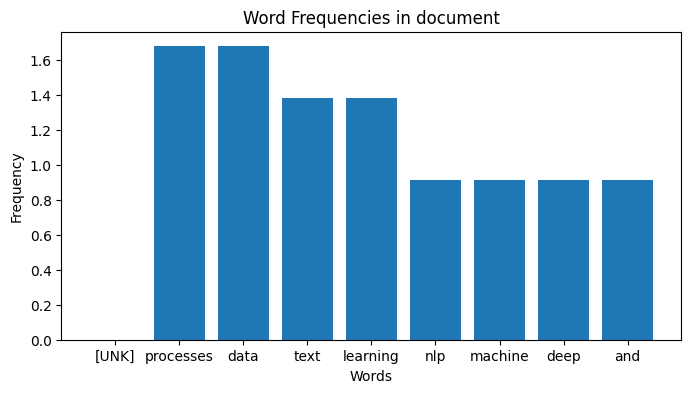

In [ ]:
words = vectorizer.get_vocabulary()
words_count = np.sum(np.array(encoded), axis = 0)

plt.figure(figsize = (8, 4))
plt.bar(words, words_count)
plt.title("Word Frequencies in document")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

## Visualizing as HeatMap

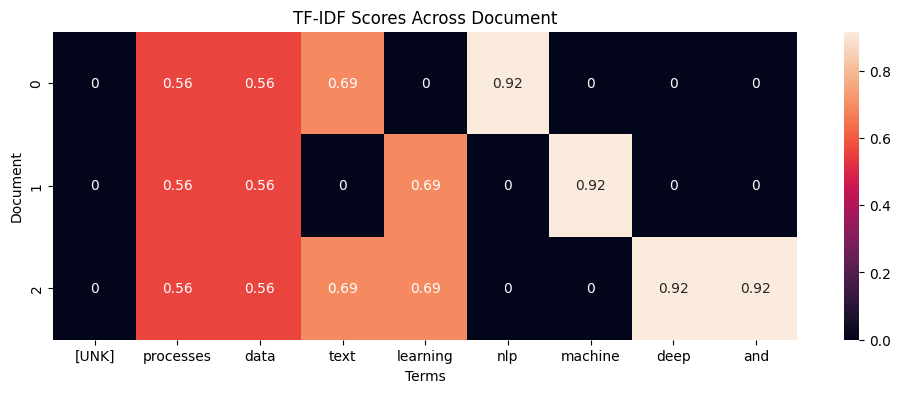

In [ ]:
df = pd.DataFrame(
    np.array(encoded),
    columns = vectorizer.get_vocabulary()
)

plt.figure(figsize = (12, 4))
sns.heatmap(df, annot = True)
plt.title("TF-IDF Scores Across Document")
plt.xlabel("Terms")
plt.ylabel("Document")
plt.show()